In [35]:
## skip this cell

# api = wandb.Api()
# proj = api.runs("philurame/SDXL_METRICS_SOLVERS")
# # cols = ['solver', 'scheduler', 'FID', 'IS', 'CLIP', 'nfe']
# cols = ['dataset', 'solver', 'scheduler', 'cacher_quantizer', 'SEC_PER_IMG', 'TFLOPS', 'bits_per_weight', 'FID', 'IS', 'CLIP', 'nfe'] 
# df = pd.DataFrame(columns = cols)
# for run in proj:  
#   hist = run.history().reindex(columns=df.columns)
#   hist = hist.assign(**run.config)
#   df = pd.concat([df, hist[cols]], ignore_index=True)
# df.nfe = df.nfe.astype(int)
# # df.to_csv('../METRICS.csv')

# Plot Solver Metrics

In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import product
import pandas.io.formats.style

ROOT = '/home/mdnikolaev/philurame/SDXL_METRICS'


########################################
# avg_delta & base_delta
########################################
def calc_bench_metrics(df):
  '''
  avg_delta = (is-ddim)/std(ddim) + (clip-ddim)/std(ddim) + (ddim - fid)/std(ddim)
  ddim = 50 - metric for (DDIM, LINEAR)

  base_delta = (is-ddim)/std(ddim) + (clip-ddim)/std(ddim) + (ddim - fid)/std(ddim)
  ddim = x - metric for (DDIM, LINEAR)
  '''
  df.loc[:, 'avg_delta'] = None
  df.loc[:, 'base_delta'] = None

  ddim = df.query('solver=="DDIM" and scheduler=="LINEAR"')
  std_IS = ddim['IS'].std()
  std_CLIP = ddim['CLIP'].std()
  std_FID = ddim['FID'].std()

  for solver, scheduler, nfe in product(df.solver.unique(), df.scheduler.unique(), df.nfe.unique()):
    mask = (df.solver==solver) & (df.scheduler==scheduler) & (df.nfe==nfe)
    ddim_avg = ddim.query('nfe==50').to_dict(orient='records')[0]
    df.loc[mask, 'avg_delta'] = (df[mask]['IS'] - ddim_avg['IS'])/std_IS + \
                                (df[mask]['CLIP'] - ddim_avg['CLIP'])/std_CLIP + \
                                (ddim_avg['FID'] - df[mask]['FID']).fillna(0)/std_FID
    
    ddim_base = ddim.query('nfe==@nfe').to_dict(orient='records')
    if len(ddim_base) == 0:
      df.loc[mask, 'base_delta'] = None
      continue
    ddim_base = ddim_base[0]
    df.loc[mask, 'base_delta'] = (df[mask]['IS'] - ddim_base['IS'])/std_IS + \
                                (df[mask]['CLIP'] - ddim_base['CLIP'])/std_CLIP + \
                                (ddim_base['FID'] - df[mask]['FID']).fillna(0)/std_FID

  df['avg_delta'] = df['avg_delta'].astype(float)
  df['base_delta'] = df['base_delta'].astype(float)
  return df


########################################
# plot FID, CLIP, IS, avg_delta
########################################
def plot_metrics(df, SOLVER):
  base = df.query('solver=="DDIM" and scheduler=="LINEAR"').sort_values(by=['nfe'])
  solver = df.query('solver==@SOLVER').sort_values(by=['nfe'])
  metrics = np.array([['FID', 'CLIP'],['IS', 'avg_delta']])
  fig, ax = plt.subplots(*metrics.shape, figsize=(25, 20))

  for i, metric in enumerate(metrics.flatten()):
    axi = ax.flatten()[i]

    mins, maxs, minb, maxb = solver[metric].min(), solver[metric].max(), base[metric].min(), base[metric].max()
    if metric in ['FID']:
      axi.set_ylim(min(mins, minb)*1.1 - maxb*0.1, maxb*1.1 - min(mins, minb)*0.1)
    else:
      axi.set_ylim(minb*1.1 - max(maxs, maxb)*0.1, max(maxs, maxb)*1.1 - minb*0.1)

    if metric!='avg_delta':
      base.plot(kind='line', x='nfe', y=metric, ax=axi, label='BASE', markersize=8, linewidth=2)
    else:
      axi.hlines(xmin=1, xmax=55, y=0, color='r')
    for scheduler in solver.scheduler.unique():
      subset = solver.query('scheduler==@scheduler').sort_values(by=['nfe'])
      subset.plot(kind='line', x='nfe', y=metric, ax=axi, label=scheduler, 
                  markersize=8, linewidth=2, style='o--')
    
    axi.set_title(metric)
    axi.grid(True, linestyle='--', alpha=0.7)
    axi.legend(fontsize=20)

  plt.tight_layout()


########################################
# styled tables
########################################
def get_styled(df, solver, nfe):
  color_columns = ['FID', 'IS', 'CLIP', 'avg_delta', 'base_delta']
  show_columns  = ['FID', 'IS', 'CLIP', 'avg_delta', 'base_delta']

  df_solver = df.query('solver==@solver and nfe==@nfe').sort_values(by=['solver', 'scheduler'])
  df_solver.index = pd.MultiIndex.from_arrays([df_solver.scheduler])
  df_solver.drop(['nfe', 'solver', 'scheduler'], axis=1, inplace=True)

  styled_df = pd.io.formats.style.Styler(df_solver[show_columns], precision=4, formatter=None)
  styled_df = styled_df.background_gradient(subset=color_columns, cmap='YlOrRd')
  return styled_df

In [30]:
metrics_path = os.path.join(ROOT, 'DATA', 'METRICS.csv')
df = pd.read_csv(metrics_path, index_col=0)
df = calc_bench_metrics(df)

##################################################
NFE=10
##################################################


,FID,IS,CLIP,avg_delta,base_delta
scheduler,,,,,
AYS,21.4436,37.2202,33.5021,-1.2833,-0.0637
DDIM,23.1657,33.9592,33.0464,-5.6592,-4.4395
KARRAS,22.2813,37.8644,33.5286,-1.3886,-0.1690
LINEAR,20.7896,37.1569,33.4267,-1.2196,0.0000
SNR,22.7430,36.9134,33.4407,-2.4588,-1.2392


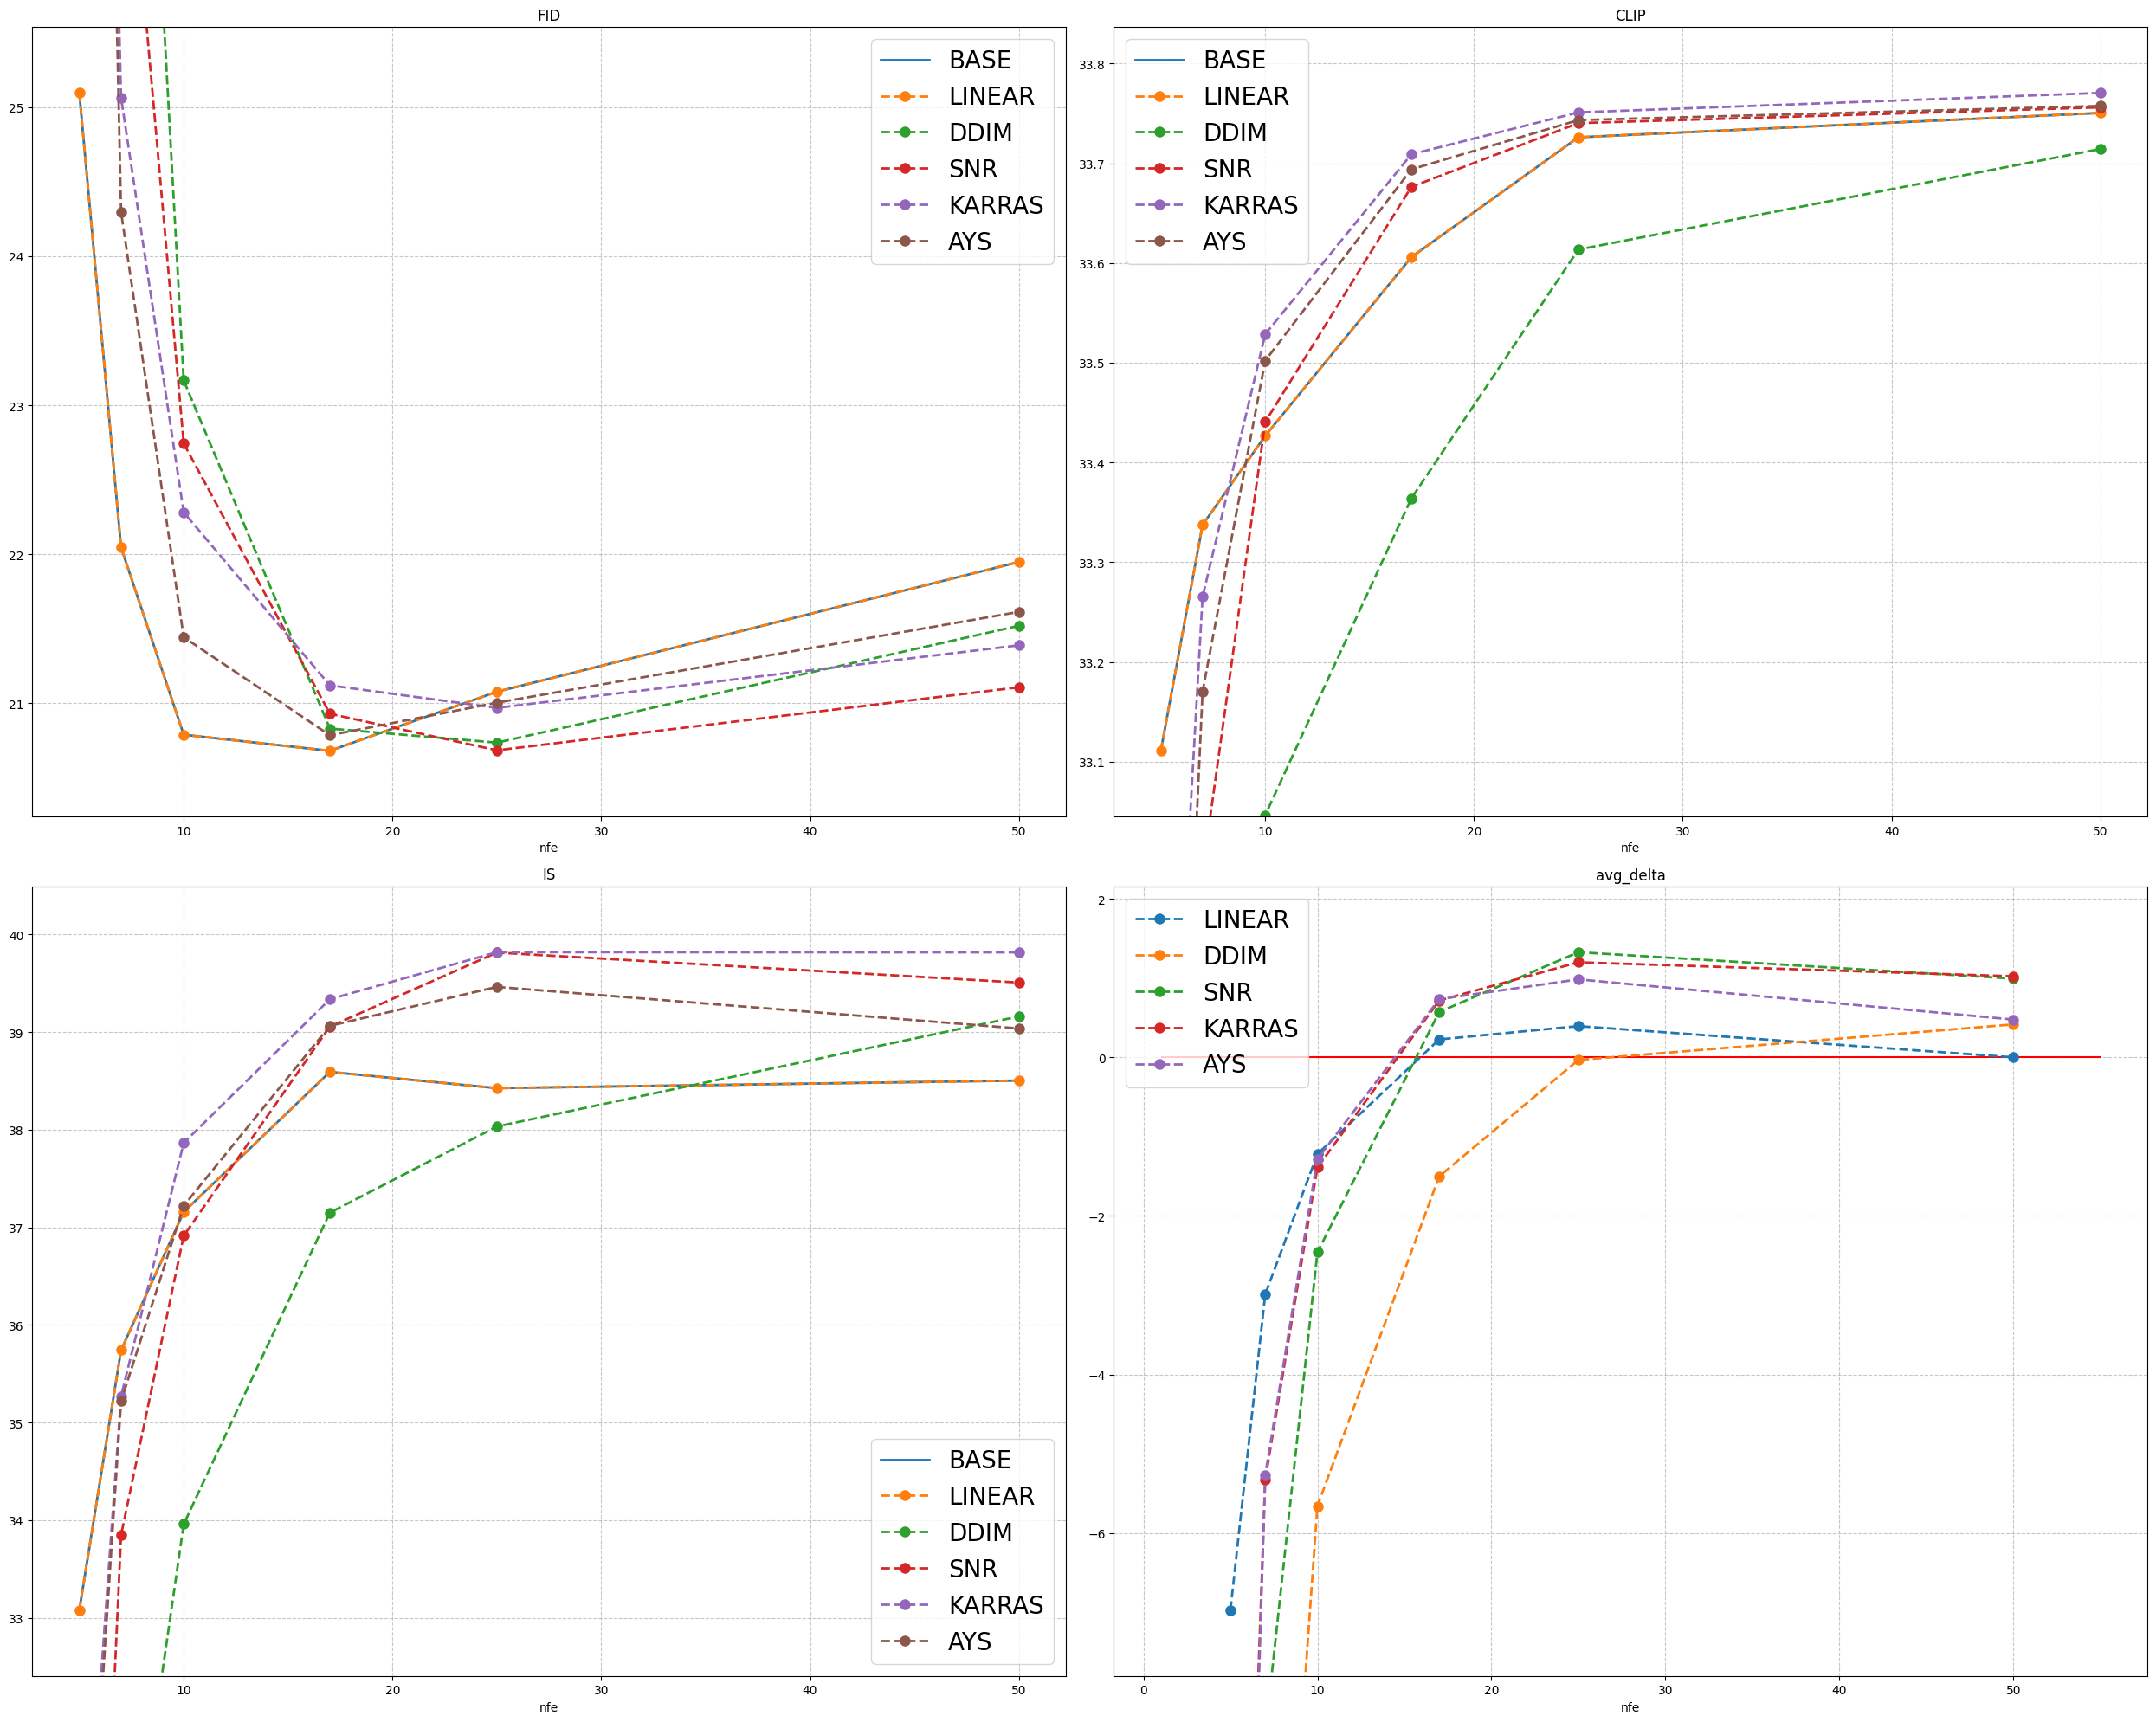

In [ ]:
from IPython.display import display
nfe = 10
print("#"*50, f'NFE={nfe}', "#"*50, sep='\n')
display(get_styled(df, 'DDIM', nfe))
print()

plot_metrics(df, 'DDIM')

## Another (better?) plot format

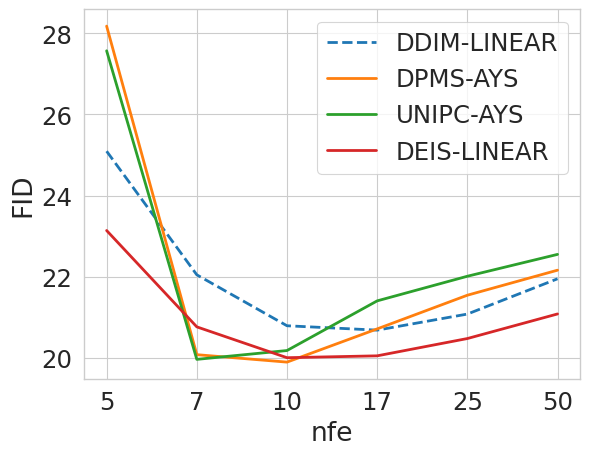

In [37]:
sns.set_style('whitegrid')
sns.set_context(
  'paper',
  font_scale=2.0,
  rc={'lines.linewidth': 2, 'lines.markersize': 10, 'figsize': (5, 4.8)}
)

def plot_sns(df_, solvers_schedulers, metric, nfe_uniform=True, plot_baseline=True):
  nfes = NFES = [5,7,10,17,25,50]
  df = df_.copy()
  if nfe_uniform:
    nfes = list(range(len(NFES)))
    df['nfe'] = df['nfe'].map(dict(zip(NFES, nfes)))

  if plot_baseline:
    sns.lineplot(data=df.query('solver=="DDIM" and scheduler=="LINEAR"').sort_values(by=['nfe']), x='nfe', y=metric, label='DDIM-LINEAR', linestyle='--')

  for solver_scheduler in solvers_schedulers:
    solver, scheduler = solver_scheduler.split('_')
    ax = sns.lineplot(data=df.query('solver==@solver and scheduler==@scheduler').sort_values(by=['nfe']), x='nfe', y=metric, label=f'{solver}-{scheduler}')
    
  ax.set_xticks(nfes)
  ax.set_xticklabels(NFES)


solvers_schedulers = ['DPMS_AYS', 'UNIPC_AYS', 'DEIS_LINEAR']

plot_sns(df, solvers_schedulers, 'FID', nfe_uniform=True)

# PICS

In [1]:
def get_imgs(solver, scheduler, NFE, N_imgs=10):
  import sys, torch
  sys.path.append(ROOT)
  from main import load_pipe
  from lib.generate_decode import decode_vae
  from lib.data import data_registry
  
  real_data = data_registry['COCO'](ROOT+'/DATA', N_imgs)

  latent_path = f'{ROOT}/DATA/NONE/COCO_{NFE}/{solver}_{scheduler}.pt'
  latents = torch.load(latent_path, map_location='cpu')[:N_imgs]

  pipe = load_pipe(solver, scheduler, 'NONE', False, True)
  imgs = decode_vae(pipe, latents)

  del pipe
  import gc
  gc.collect()
  torch.cuda.empty_cache()
  
  return imgs, real_data

def plot_imgs(i, imgs_S1, imgs_S2, SOLVER1, SOLVER2):
  import matplotlib.pyplot as plt
  fig, ax = plt.subplots(1, 2, figsize=(20, 10))
  ax[0].imshow(imgs_S1[i].permute(1, 2, 0))
  ax[1].imshow(imgs_S2[i].permute(1, 2, 0))
  ax[0].set_title(SOLVER1)
  ax[1].set_title(SOLVER2)
  ax[0].xaxis.set_visible(False)
  ax[0].yaxis.set_visible(False)
  ax[1].xaxis.set_visible(False)
  ax[1].yaxis.set_visible(False)
  plt.show()

In [ ]:
SOLVER1 = 'DEIS3'
SOLVER2 = 'DEIS'
NFE = 17

imgs_S1, real_data = get_imgs(SOLVER1, 'LINEAR', NFE)
imgs_S2, real_data = get_imgs(SOLVER2, 'LINEAR', NFE)

In [21]:
for n, i in enumerate(real_data.anns):
  sn = '\n'
  print(f'{n}: {i.split(sn)[0][:300]}')

0: A narrow city street with pedestrians and cars looking towards a domed building.
1: A hipster wearing glasses and a tie in front of a wooden wall.
2: A boat on the beach with the ocean in the background.
3: Large kites shaped like cats compete with a kite that resembles a red lizard.
4: a tortoiseshell cat stands on a couch staring hard at something in front of it
5: A white surfboard with a sign in the background that reads "billabong."
6: There is a close up picture of a side view of a zebras face
7: a person holding an opened umbrella standing in front of several colorful trees
8: A small boy in a red and white shirt and black cap holding a toothbrush in his mouth.
9: two pieces of toast, bacon and potatoes on a table with a cup of coffee


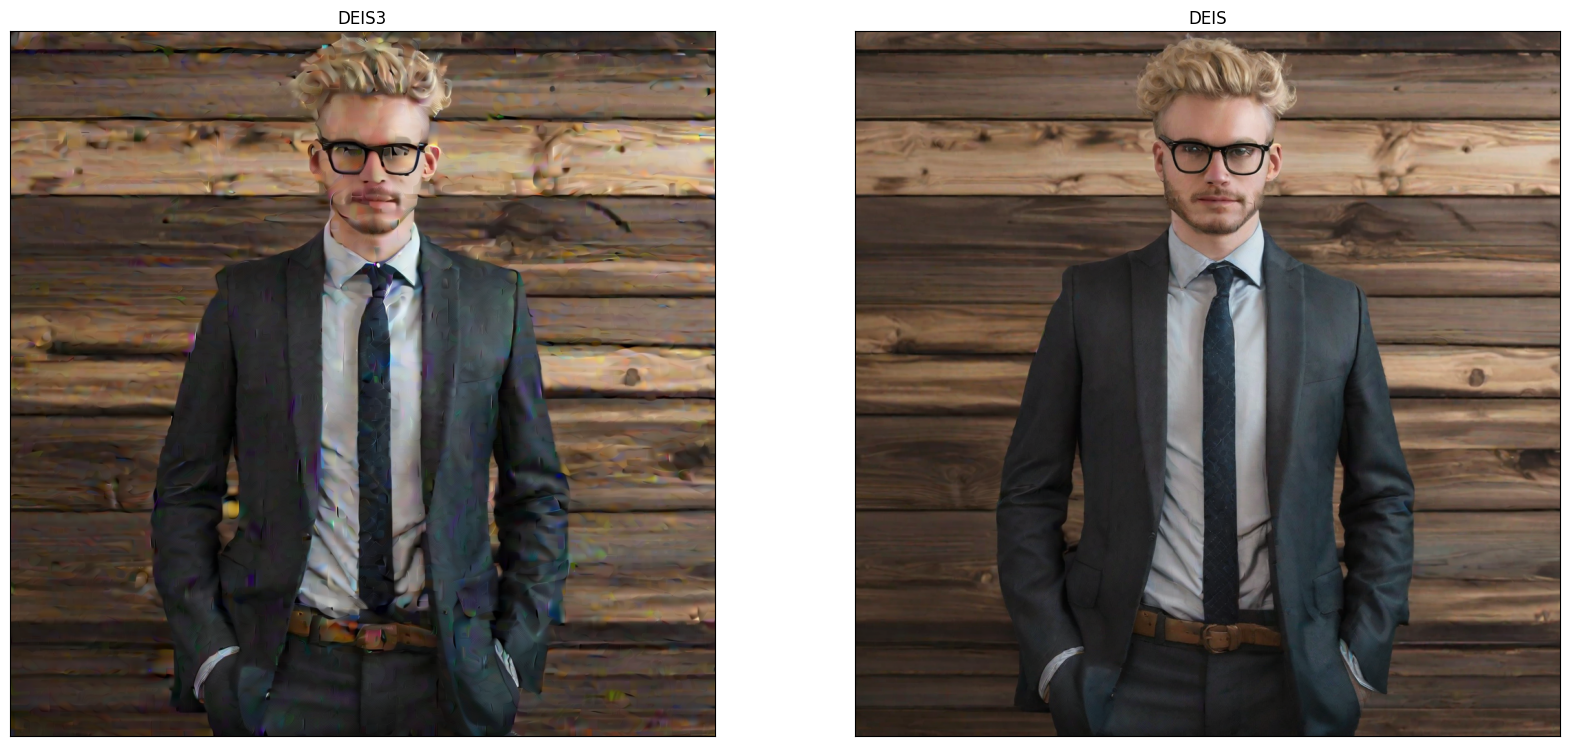

In [31]:
plot_imgs(i=1, imgs_S1=imgs_S1, imgs_S2=imgs_S2, SOLVER1=SOLVER1, SOLVER2=SOLVER2)